# 1.5 - Manual clustering (tune, eyeball & merge)

Self-contained tuning playground. Everything is in this notebook: it **fits
k-means here**, draws every cluster, and lets you merge them by hand. No
silhouette / elbow / scoring - you decide from the pictures.

**Tune** the two knobs at the top (`K` and `DAY_WEIGHTS`), then re-run top to
bottom -> the clusters update. Retroflection lives at day 30-50, the destination
at day 180

1. Fit k-means (weighted, standardized - same space as the pipeline).
2. Grid: orange = centroid track, grey = full member trajectories.
3. Hand-assign each cluster a **group letter** in `ASSIGN` (same letter = merged).
4. Last cell prints `GROUP_MAP` / `GROUP_NAMES` to paste into `config.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root: config.py, pipeline.py
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import config as C
import pipeline as P
import matplotlib.patches as mpatches

# --- TUNE ME -----------------------------------------------------------------
K = 70      # over-resolve: minority pathways (retroflection) need enough clusters

# Per-day weights, tuned HERE without touching config.py (nb02/03 still use config).
# Set DAY_WEIGHTS = None to fall back to config.DAY_WEIGHTS.
# U-shape below: emphasise retroflection (day 30-50) AND the endpoint (day 180).
DAY_WEIGHTS = {30: 0.5, 50: 1.5, 100: 1.0, 150: 1.5, 180: 2.0}
# -----------------------------------------------------------------------------

_wd = DAY_WEIGHTS if DAY_WEIGHTS is not None else C.DAY_WEIGHTS
W   = np.array([np.sqrt(_wd[d]) for d in C.DAYS for _ in range(2)])   # sqrt(w) per column
print("days:", C.DAYS, "| K:", K, "| weights:", _wd)

days: [30, 50, 100, 150, 180] | K: 70 | weights: {30: 0.5, 50: 1.5, 100: 1.0, 150: 1.5, 180: 2.0}


## Fit k-means (here, so tuning re-clusters)
Standardize each day to mean 0 / std 1, apply the per-day weights `W`, then fit.
Change `K` or `DAY_WEIGHTS` above and re-run this cell to get new clusters.

In [2]:
features = pd.read_parquet(C.FEATURES_FILE)
complete = features[features.status == "complete"]
sub = complete.sample(n=min(C.N_SUB, len(complete)),
                      random_state=C.RANDOM_STATE).reset_index(drop=True)

X_raw  = P.build_feature_matrix(sub)                      # raw degrees
scaler = StandardScaler().fit(X_raw)
X_sub  = scaler.transform(X_raw) * W                      # standardized + weighted

km = MiniBatchKMeans(n_clusters=K, random_state=C.RANDOM_STATE,
                     batch_size=10000, n_init=100, max_iter=300)
labels = km.fit_predict(X_sub)
sizes  = np.bincount(labels, minlength=K)

# centroids back to real degrees: [lat_d0, lon_d0, lat_d1, lon_d1, ...]
cent_deg = P.centroids_to_degrees(km.cluster_centers_ / W, scaler)
print(f"fit k={K} on {len(sub):,} trajectories | cluster sizes {sizes.min()}..{sizes.max()}")

fit k=70 on 500,000 trajectories | cluster sizes 1002..94409


In [3]:
# Persist THIS fit. Notebook 1.5 otherwise keeps the model only in memory, so
# the grouping in ASSIGN would be anchored to cluster ids that die with the
# kernel. Written to its own subdirectory: notebook 02 writes kmeans_k*.pkl and
# scaler.pkl into MODELS_DIR itself and would overwrite them.
# import joblib, json as _json
# MODEL_DIR = C.MODELS_DIR / f"manual_1.5_k{K}"
# MODEL_DIR.mkdir(parents=True, exist_ok=True)
# joblib.dump(km, MODEL_DIR / f"kmeans_k{K}.pkl")
# joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
# np.save(MODEL_DIR / "weights_W.npy", W)
# np.save(MODEL_DIR / "centroids_deg.npy", cent_deg)
# pd.DataFrame({"trajectory_id": sub.trajectory_id.to_numpy(),
#               "cluster": labels}).to_parquet(
#     MODEL_DIR / "subsample_labels.parquet", index=False)
# (MODEL_DIR / "fit_metadata.json").write_text(_json.dumps(dict(
#     source_notebook="1.5_Manual_clustering.ipynb", K=K,
#     DAY_WEIGHTS={str(k): v for k, v in _wd.items()}, DAYS=C.DAYS,
#     N_SUB=C.N_SUB, RANDOM_STATE=C.RANDOM_STATE, n_fitted=int(len(sub)),
#     cluster_sizes=sizes.tolist()), indent=2))
# print("saved model ->", MODEL_DIR)


## Cheap coastline
Coarsest Natural Earth coastline (110 m) loaded **once** as plain (lon, lat)
segments and drawn as thin grey lines on ordinary axes -> a map backdrop without
a cartopy GeoAxes per panel.

In [4]:
import cartopy.feature as cfeature
lon = (C.DOMAIN["lon_min"], C.DOMAIN["lon_max"])
lat = (C.DOMAIN["lat_min"], C.DOMAIN["lat_max"])

_coast = []
for geom in cfeature.COASTLINE.with_scale("110m").geometries():
    for line in getattr(geom, "geoms", [geom]):
        _coast.append((np.asarray(line.xy[0]), np.asarray(line.xy[1])))

def draw_coast(ax):
    for x, y in _coast:
        ax.plot(x, y, "-", color="0.75", lw=.4, zorder=0)
    ax.set_xlim(*lon); ax.set_ylim(*lat)
print("coastline segments:", len(_coast))

coastline segments: 134


## All clusters on one map
Every centroid track together (no particle trajectories) - one overview of how
the `K` clusters spread. Number = cluster id at its day-{last} endpoint.

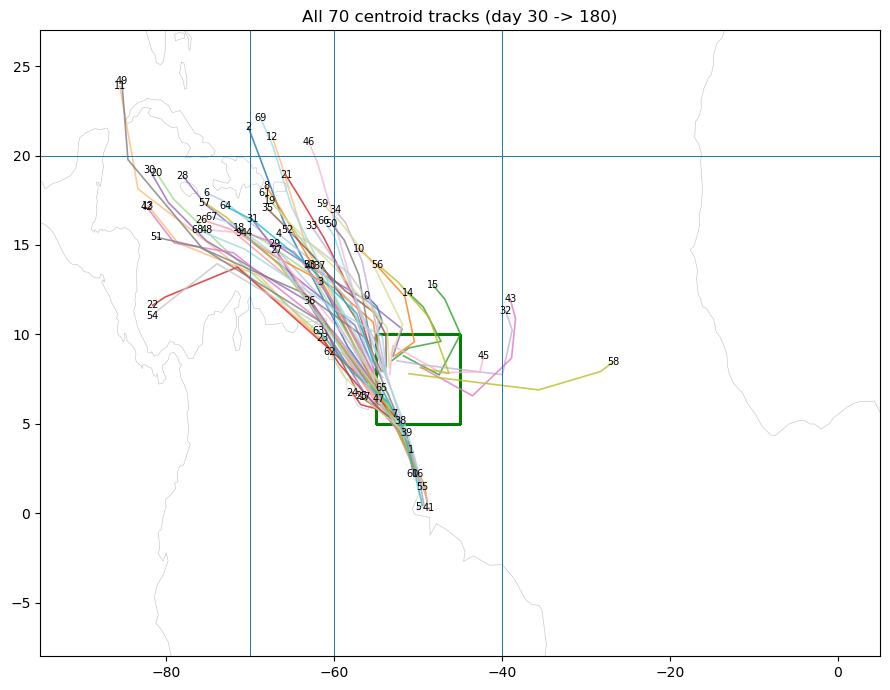

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
draw_coast(ax)
allcmap = plt.get_cmap("tab20", K)
for c in range(K):
    lo, la = cent_deg[c, 1::2], cent_deg[c, 0::2]      # centroid track (degrees)
    ax.plot(lo, la, "-", color=allcmap(c), lw=1.2, alpha=.8, zorder=2)
    # ax.plot(lo[-1], la[-1], "o", color=allcmap(c), mec="k", ms=5, zorder=
    ax.axvline(-70,linewidth=0.5)
    ax.axvline(-60,linewidth=0.5)
    ax.axhline(20,linewidth=0.5)
    ax.axvline(-40,linewidth=0.5)
    rect= mpatches.Rectangle(
    xy=(-55, 5),
    width=10,
    height=5,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(lo[-1], la[-1], str(c), fontsize=7, ha="center", va="center", zorder=4)
ax.set_title(f"All {K} centroid tracks (day {C.DAYS[0]} -> {C.DAYS[-1]})")
fig.tight_layout(); plt.show()


## Stream a few FULL member trajectories per cluster
Pick `MEMBERS_PER_PANEL` trajectory_ids per cluster and read their whole
`lon`/`lat` path from Zarr (open each store once). Bounded I/O:
`K x MEMBERS_PER_PANEL` paths.

In [6]:
MEMBERS_PER_PANEL = 12
N_IO_THREADS = int(os.environ.get("SLURM_CPUS_PER_TASK", 16))
stores = C.list_stores()

memdf = pd.DataFrame({"trajectory_id": sub.trajectory_id.to_numpy(), "lab": labels})
pick = (memdf.groupby("lab", group_keys=False)
              .apply(lambda d: d.sample(min(MEMBERS_PER_PANEL, len(d)),
                                        random_state=C.RANDOM_STATE)))
pick["store_index"] = pick.trajectory_id // C.TRAJ_PER_STORE
pick["local"]       = pick.trajectory_id %  C.TRAJ_PER_STORE

def _read_paths(si, grp):
    ds  = xr.open_zarr(stores[si])
    loc = grp.local.to_numpy()
    return grp.trajectory_id.to_numpy(), ds.lon.values[loc], ds.lat.values[loc]

res = Parallel(n_jobs=N_IO_THREADS, backend="threading")(
    delayed(_read_paths)(si, grp) for si, grp in pick.groupby("store_index"))

paths = {}                                        # trajectory_id -> (lon[obs], lat[obs])
for tids, plon, plat in res:
    for j, tid in enumerate(tids):
        paths[int(tid)] = (plon[j], plat[j])
members = {c: pick.loc[pick.lab == c, "trajectory_id"].to_numpy() for c in range(K)}
print(f"streamed {len(paths):,} full trajectories from {pick.store_index.nunique()} stores")

/tmp/ipykernel_3104619/2995321380.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(min(MEMBERS_PER_PANEL, len(d)),


streamed 840 full trajectories from 622 stores


## Assign each cluster a group letter
`ASSIGN[cluster] = "letter"`. Same letter => merged. Start all-separate and merge
by reading the grid above (e.g. collect the retroflection clusters into one letter).

In [8]:
# Grouping transferred onto the K=70 fit from cluster_K50_GROUPED.pdf:
# each new centroid inherits the letter of its nearest OLD centroid
# (data/kmeans_models/manual_1.5_k50/), same metric as cell 16.
# Median match 2.9 deg, 90th pct 4.6, max 7.6.
# Table with distances + runner-up: data/grouping_transfer_k70.csv
# MANUAL EDIT: 8 moved BS -> B2. It is the only BS cluster already inside the
# B2 area (-70<lon<-60, lat<20) at day 100, at (12.3,-60.7); the rest of BS is
# still at 1.7-9.5 N and east of -57 then. Caveat: 8 also has the most extreme
# shelf start in the whole fit (0.5 N at d30, 1.6 N at d50) - it is shelf-bound
# early and then transits fast, so it is a genuine boundary case.
ASSIGN = {
   0:"C",     1:"E1",    2:"B1",    3:"BS",    4:"B2",    5:"E2",     6:"A2",    7:"E0",    8:"BS",    9:"B2",
   10:"C",    11:"A1",   12:"B1",   13:"A2",   14:"C",    15:"C",    16:"E2",   17:"S",    18:"B2",   19:"B2",
   20:"A2",   21:"B2",   22:"A3",   23:"S1",   24:"S",    25:"S",    26:"A2",   27:"BS",   28:"A2",   29:"B2",
   30:"A2",   31:"BS",   32:"F",    33:"BS",   34:"CB",   35:"B2",   36:"S1",   37:"CB",   38:"E1",   39:"E1",
   40:"BS",   41:"E2",    42:"A2",   43:"F",    44:"B2",   45:"F",    46:"B1",   47:"E0",   48:"A2",   49:"A1",
   50:"B2",   51:"A2",   52:"B2",   53:"B2",   54:"A3",   55:"E2",    56:"C",    57:"A2",   58:"F",    59:"CB",
   60:"E2",   61:"B2",   62:"S1",   63:"S1",   64:"B2",   65:"S",    66:"BS",   67:"A2",   68:"A2",   69:"B1",
}


## The grid - one panel per cluster
Grey coastline + grey full member paths + orange centroid track (first -> last
day in `C.DAYS`). This is the picture you group from.

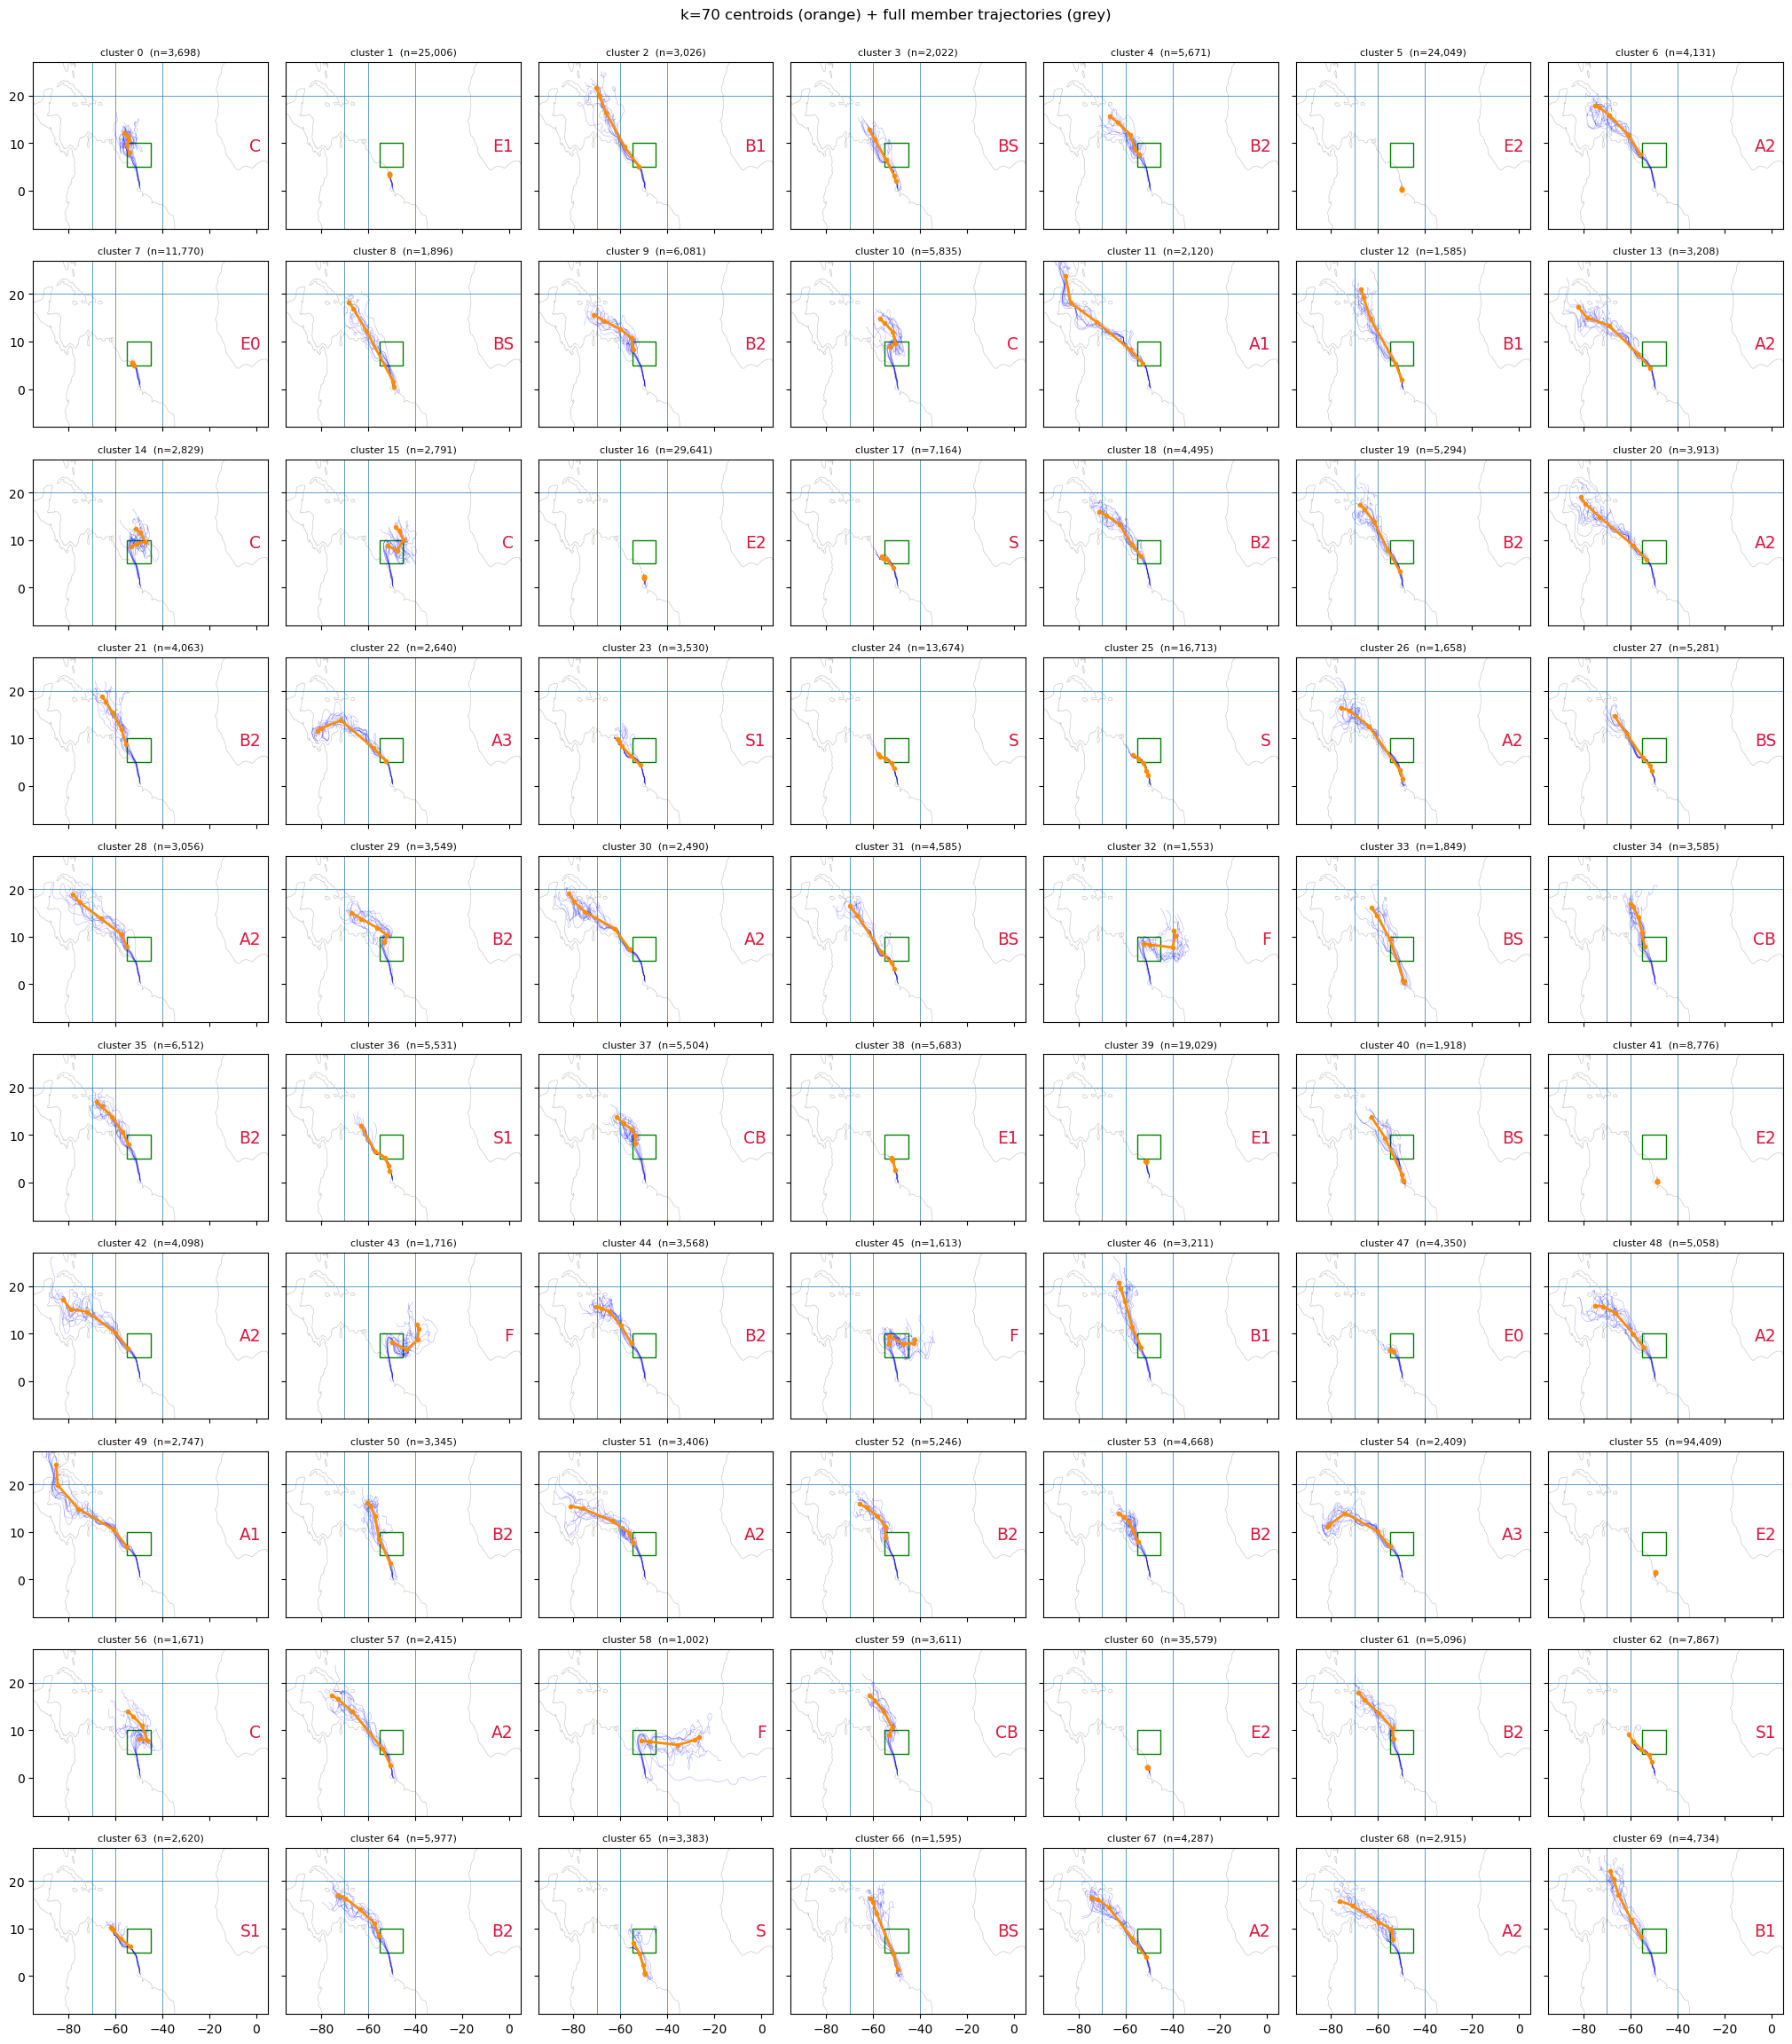

In [9]:
NCOL = 7
LETTER_FRAC = 0.10          # group letter height, as a fraction of the y axis

def draw_cluster(ax, c):
    draw_coast(ax)
    for tid in members[c]:
        lo, la = paths[int(tid)]
        m = ~(np.isnan(lo) | np.isnan(la))             # drop the NaN tail (early-ended)
        ax.plot(lo[m], la[m], "-", color="blue", lw=.4, alpha=.3)
    clo, cla = cent_deg[c, 1::2], cent_deg[c, 0::2]    # centroid
    ax.plot(clo, cla, ".-", color="darkorange", lw=2, zorder=3)

nrow = int(np.ceil(K / NCOL))
fig, axes = plt.subplots(nrow, NCOL, figsize=(2.9 * NCOL, 2.3 * nrow),
                         squeeze=False, sharex=True, sharey=True)
labels = []
for c in range(K):
    ax = axes[c // NCOL][c % NCOL]
    draw_cluster(ax, c)
    ax.set_title(f"cluster {c}  (n={sizes[c]:,})", fontsize=8)

    ax.axvline(-70,linewidth=0.5)
    ax.axvline(-60,linewidth=0.5)
    ax.axhline(20,linewidth=0.5)
    ax.axvline(-40,linewidth=0.5)
    rect= mpatches.Rectangle(
    xy=(-55, 5),
    width=10,
    height=5,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
    )
    ax.add_patch(rect)

    # group letter, middle-right of the panel
    labels.append((ax, ax.text(0.97, 0.5, ASSIGN[c], transform=ax.transAxes,
                               ha="right", va="center", fontsize=20,
                               color="crimson", zorder=6)))

for j in range(K, nrow * NCOL):
    axes[j // NCOL][j % NCOL].axis("off")
fig.suptitle(f"k={K} centroids (orange) + full member trajectories (grey)", y=1.0)
fig.tight_layout()

# scale the letters so each is at least LETTER_FRAC of its panel's height.
# Done after tight_layout, since that is what fixes the final axes size.
fig.canvas.draw()
rend = fig.canvas.get_renderer()
for ax, txt in labels:
    h_ax  = ax.get_window_extent(rend).height
    h_txt = txt.get_window_extent(rend).height
    txt.set_fontsize(txt.get_fontsize() * (LETTER_FRAC * h_ax / h_txt))
fig.canvas.draw()

# fig.savefig(f"cluster_K{K}_W_{_wd}.pdf", dpi=130, bbox_inches="tight")
plt.show()


## Preview the merged groups
One panel per letter, overlaying every centroid you assigned to it. Lines
disagree -> split; two panels look identical -> merge.

Points are coloured by **day** (dark = day 30, yellow = day 180), not by
cluster: inside a panel every centroid belongs to the same group, so cluster
identity says nothing, while the direction and pace of travel does. The grey
line just joins each centroid's own five points.


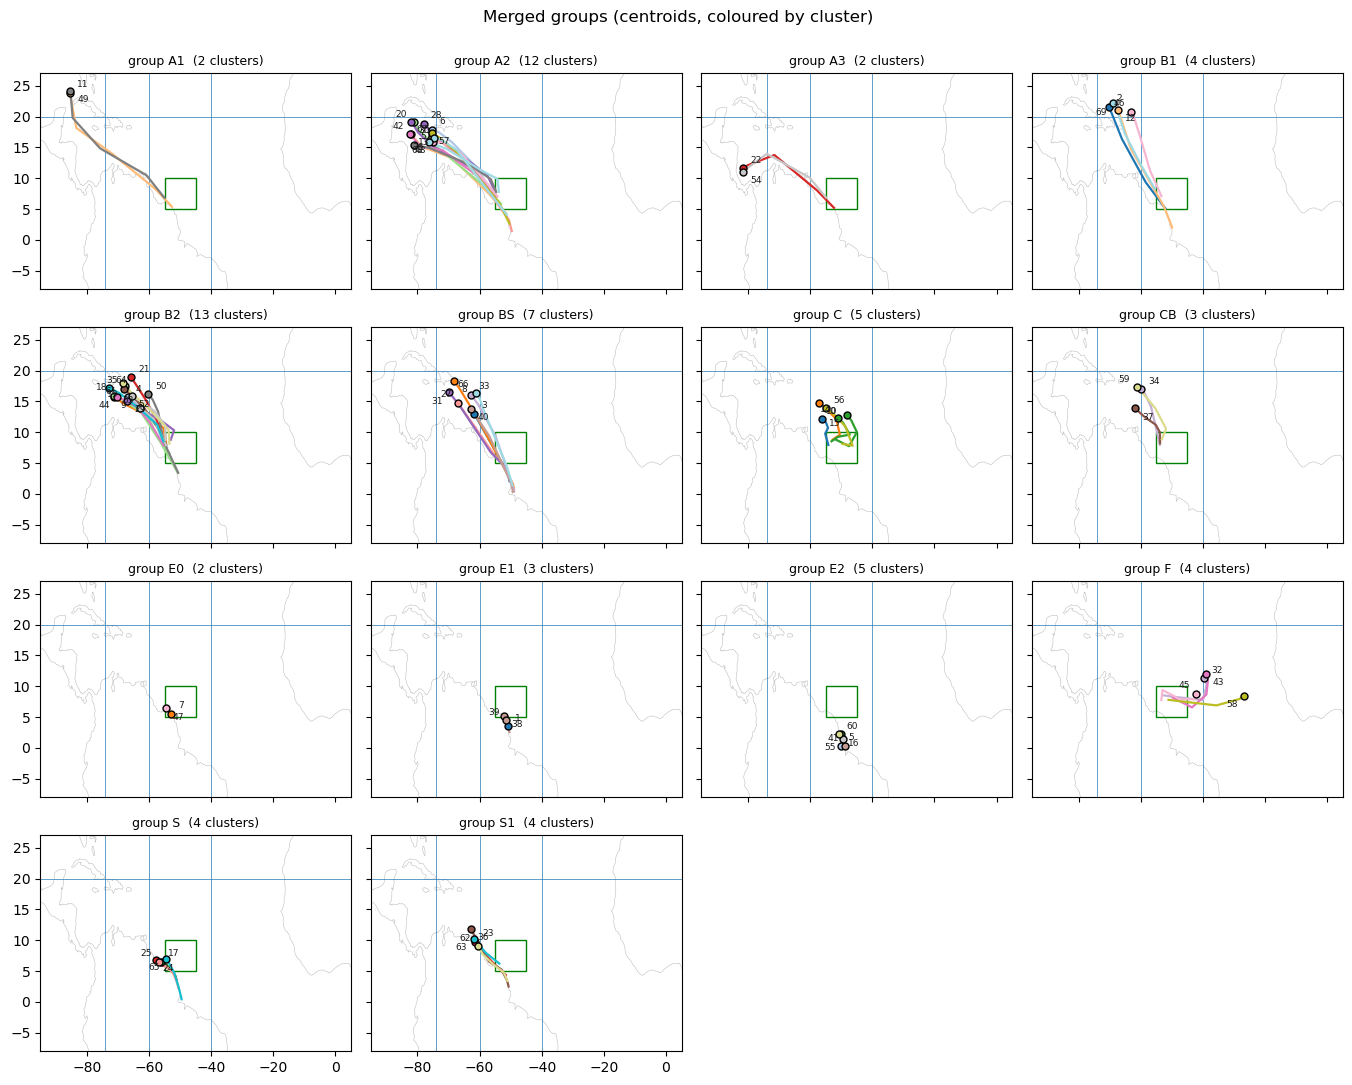

In [10]:
# same panels, coloured by CLUSTER instead of by day
letters = sorted(set(ASSIGN.values()))
NCOLg = min(4, len(letters))
nrowg = int(np.ceil(len(letters) / NCOLg))
cmap  = plt.get_cmap("tab20", K)

fig, axes = plt.subplots(nrowg, NCOLg, figsize=(3.4 * NCOLg, 2.7 * nrowg),
                         squeeze=False, sharex=True, sharey=True)
for i, L in enumerate(letters):
    ax  = axes[i // NCOLg][i % NCOLg]
    draw_coast(ax)
    for x in (-74, -60, -40):
        ax.axvline(x, linewidth=0.5)
    ax.axhline(20, linewidth=0.5)
    ax.add_patch(mpatches.Rectangle(xy=(-55, 5), width=10, height=5,
                                    linewidth=1, edgecolor='green',
                                    facecolor='none'))
    mem = [c for c in range(K) if ASSIGN[c] == L]
    for c in mem:
        lo, la = cent_deg[c, 1::2], cent_deg[c, 0::2]
        ax.plot(lo, la, "-", color=cmap(c), lw=1.6, zorder=2)
        ax.plot(lo[-1], la[-1], "o", color=cmap(c), mec="k", ms=5, zorder=3)
        off = [(5, 4), (5, -8), (-13, 4), (-13, -8)][mem.index(c) % 4]
        ax.annotate(str(c), (lo[-1], la[-1]), xytext=off,
                    textcoords="offset points", fontsize=6.5, color="0.1",
                    zorder=5,
                    )
    ax.set_title(f"group {L}  ({len(mem)} clusters)", fontsize=9)
for j in range(len(letters), nrowg * NCOLg):
    axes[j // NCOLg][j % NCOLg].axis("off")
fig.suptitle("Merged groups (centroids, coloured by cluster)", y=1.0)
fig.tight_layout(); plt.show()


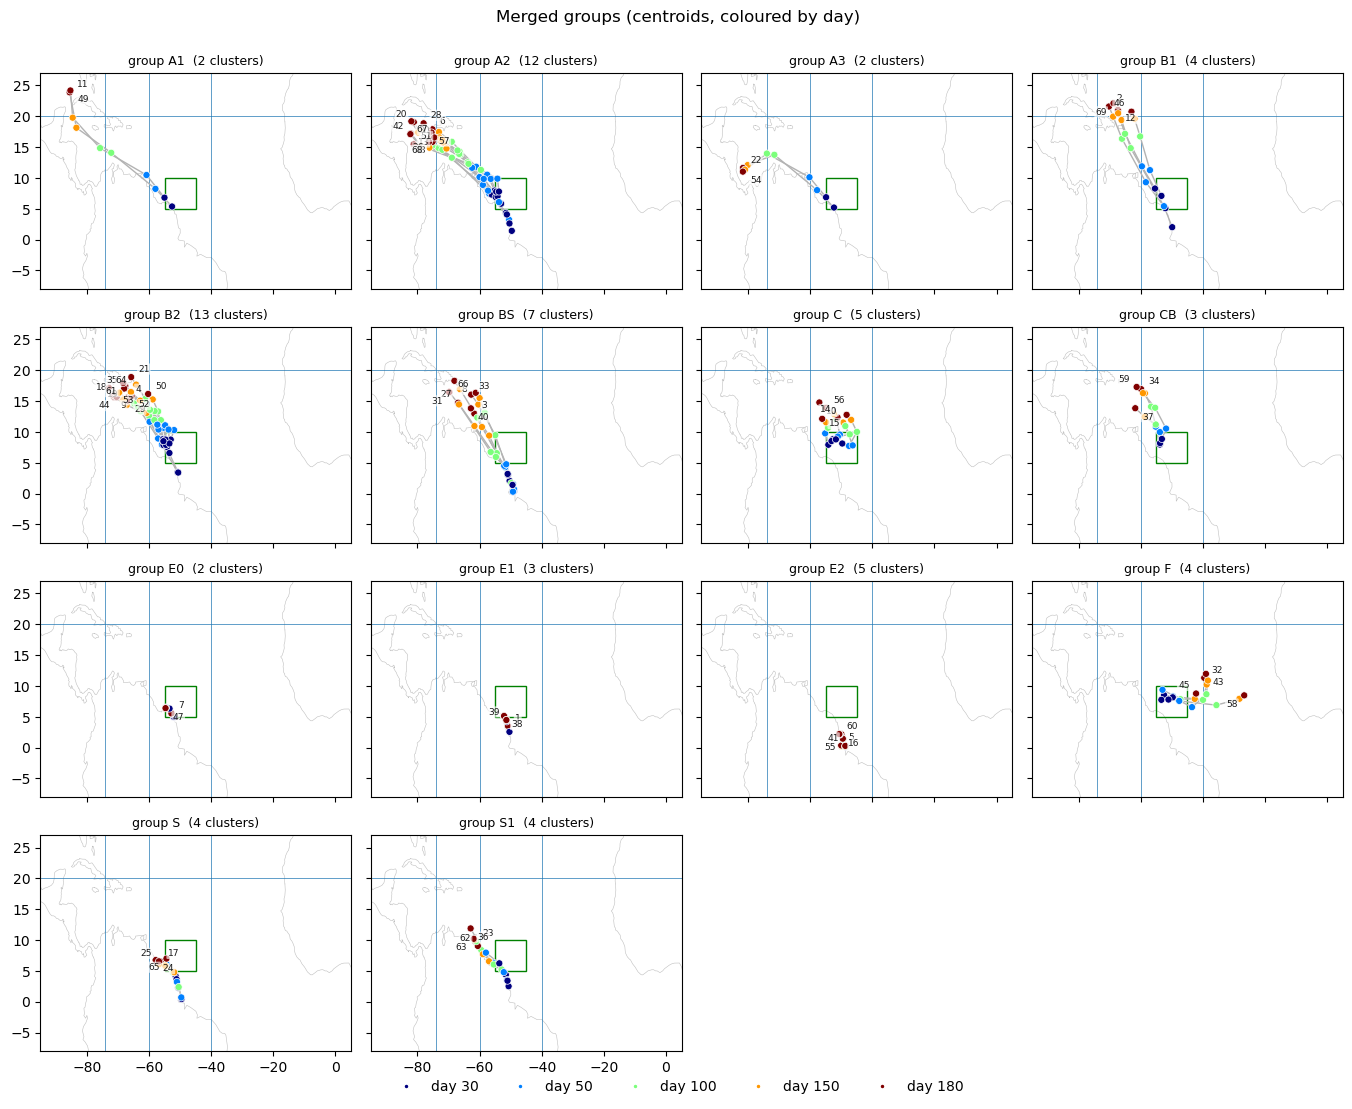

In [11]:
letters = sorted(set(ASSIGN.values()))
NCOLg = min(4, len(letters))
nrowg = int(np.ceil(len(letters) / NCOLg))

# colour by DAY, not by cluster: within a panel every centroid is the same
# group, so cluster identity carries nothing - but seeing which end of each
# track is day 30 and which is day 180 does.
daycmap = plt.get_cmap("jet", len(C.DAYS))
daycol  = [daycmap(i) for i in range(len(C.DAYS))]

fig, axes = plt.subplots(nrowg, NCOLg, figsize=(3.4 * NCOLg, 2.7 * nrowg),
                         squeeze=False, sharex=True, sharey=True)
for i, L in enumerate(letters):
    ax  = axes[i // NCOLg][i % NCOLg]
    draw_coast(ax)
    for x in (-74, -60, -40):
        ax.axvline(x, linewidth=0.5)
    ax.axhline(20, linewidth=0.5)
    ax.add_patch(mpatches.Rectangle(xy=(-55, 5), width=10, height=5,
                                    linewidth=1, edgecolor='green',
                                    facecolor='none'))
    mem = [c for c in range(K) if ASSIGN[c] == L]
    for c in mem:
        lo, la = cent_deg[c, 1::2], cent_deg[c, 0::2]
        ax.plot(lo, la, "-", color="0.7", lw=1.0, zorder=2)      # the track itself
        ax.scatter(lo, la, c=daycol, s=26, zorder=3,
                   edgecolor="white", linewidths=.5)
        # cluster id, offset staggered so neighbouring labels do not stack
        off = [(5, 4), (5, -8), (-13, 4), (-13, -8)][mem.index(c) % 4]
        ax.annotate(str(c), (lo[-1], la[-1]), xytext=off,
                    textcoords="offset points", fontsize=6.5, color="0.1",
                    zorder=5,
                    bbox=dict(boxstyle="round,pad=0.12", fc="white",
                              ec="none", alpha=.65))
    ax.set_title(f"group {L}  ({len(mem)} clusters)", fontsize=9)
for j in range(len(letters), nrowg * NCOLg):
    axes[j // NCOLg][j % NCOLg].axis("off")

handles = [plt.Line2D([], [], marker=".", ls="", color=daycol[i], mec="white",
                      ms=7, label=f"day {d}") for i, d in enumerate(C.DAYS)]
fig.legend(handles=handles, loc="lower center", ncol=len(C.DAYS), frameon=False,
           bbox_to_anchor=(0.5, -0.015))
fig.suptitle("Merged groups (centroids, coloured by day)", y=1.0)
fig.tight_layout(); plt.show()


In [12]:
from itertools import combinations
def cdist(a, b):                       # geo distance between two full centroid tracks (deg)
    return float(np.sqrt(((cent_deg[a] - cent_deg[b])**2).sum()))

print("group  n  max_within_dist(deg)  members")
for L in sorted(set(ASSIGN.values())):
    m = [c for c in range(K) if ASSIGN[c] == L]
    spread = max((cdist(a, b) for a, b in combinations(m, 2)), default=0.0)
    flag = "  <-- loose?" if spread > 12 else ""
    print(f"  {L:4s} {len(m):2d}      {spread:6.1f}            {m}{flag}")

print("\nclosest different-label cluster pairs (merge/boundary candidates):")
pairs = sorted((cdist(a, b), a, b) for a, b in combinations(range(K), 2) if ASSIGN[a] != ASSIGN[b])
for d, a, b in pairs[:12]:
    print(f"  {d:5.1f} deg : {a}({ASSIGN[a]})  <->  {b}({ASSIGN[b]})")


group  n  max_within_dist(deg)  members
  A1    2         6.2            [11, 49]
  A2   12        23.0            [6, 13, 20, 26, 28, 30, 42, 48, 51, 57, 67, 68]  <-- loose?
  A3    2         5.2            [22, 54]
  B1    4        13.3            [2, 12, 46, 69]  <-- loose?
  B2   13        19.5            [4, 9, 18, 19, 21, 29, 35, 44, 50, 52, 53, 61, 64]  <-- loose?
  BS    7        20.7            [3, 8, 27, 31, 33, 40, 66]  <-- loose?
  C     5        16.9            [0, 10, 14, 15, 56]  <-- loose?
  CB    3         6.4            [34, 37, 59]
  E0    2         4.6            [7, 47]
  E1    3         3.9            [1, 38, 39]
  E2    5         6.1            [5, 16, 41, 55, 60]
  F     4        24.9            [32, 43, 45, 58]  <-- loose?
  S     4        11.5            [17, 24, 25, 65]
  S1    4        14.7            [23, 36, 62, 63]  <-- loose?

closest different-label cluster pairs (merge/boundary candidates):
    2.9 deg : 1(E1)  <->  60(E2)
    3.5 deg : 7(E0)  <->  38(

## Distance of every cluster from the `REF_GROUP` centroids
`REF_GROUP` has one centroid per sampled day; the y axis is those centroid
**locations** (lat, lon), one row each. For each row, the x axis is how far
every other cluster's centroid sits from that `REF_GROUP` centroid, in degrees.
One line per cluster, coloured by broad letter.

Lines start bunched near the release point and spread out downstream: where a
line pulls away marks where that pathway stops following `REF_GROUP`. A line
still low at the last centroid is a merge candidate; a colour sitting inside
another colour's bundle is worth re-checking in `ASSIGN`.


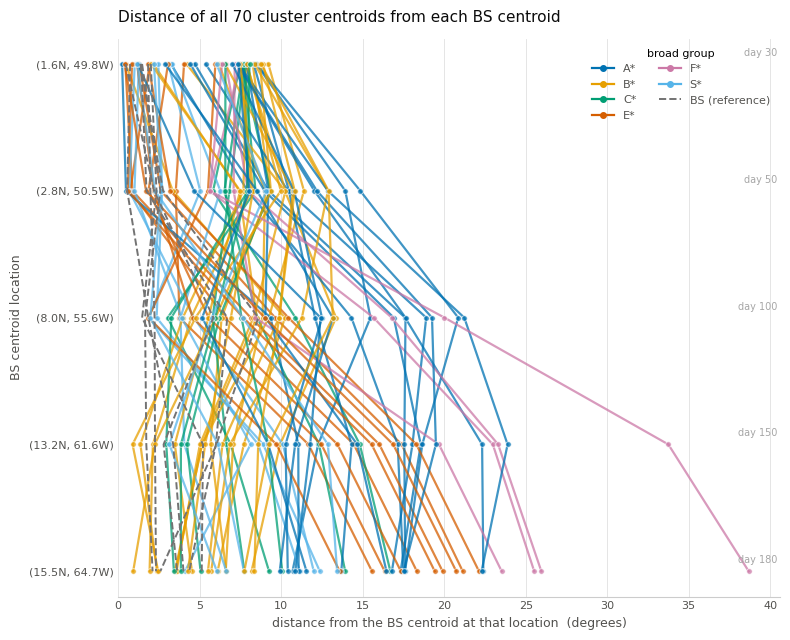

distance from group BS (clusters [3, 8, 27, 31, 33, 40, 66]) per day, degrees

 clus  grp  d   30  d   50  d  100  d  150  d  180
   52  B2      8.7     9.4     6.0     2.2     0.9
    4  B2      7.5     8.1     4.5     2.1     1.9
   33  BS      1.5     2.6     1.6     1.7     2.1
   27  BS      1.8     2.0     2.2     2.3     2.3
   29  B2      7.9     7.7     4.0     1.4     2.4
   53  B2      7.9    10.0     4.7     0.9     2.4
   40  BS      1.4     2.7     8.6     6.0     2.6
   37  CB      7.7     7.9     3.3     2.9     3.4
   19  B2      2.2     7.4     8.5     5.1     3.5
   21  B2      9.2    11.4     9.2     5.1     3.5
   35  B2      7.9    10.3     8.3     5.0     3.6
   66  BS      0.4     2.2     5.8     2.8     3.6
   59  CB      8.1     7.9     5.9     3.8     3.8
    3  BS      0.7     0.5     1.8     3.4     4.0
   36  S1      1.3     1.0     3.9     8.1     4.1
   61  B2      7.5     8.3     6.9     5.3     4.3
    8  BS      1.4     1.7     6.7     6.0     4.4
   

In [13]:
REF_GROUP = "BS"          # any letter used in ASSIGN

# cent_deg row layout: [lat_d0, lon_d0, lat_d1, lon_d1, ...] -> (K, n_days, 2)
tracks = cent_deg.reshape(K, len(C.DAYS), 2)
ref_members = [c for c in range(K) if ASSIGN[c] == REF_GROUP]
ref = tracks[ref_members].mean(axis=0)                  # (n_days, 2) mean track

# distance at EACH day, not collapsed over days
dist = np.sqrt(((tracks - ref) ** 2).sum(axis=2))       # (K, n_days) degrees

broad = sorted({ASSIGN[c][0] for c in range(K)})        # A, B, C, E, F, S

PAL = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#000000",  # black
]

color = {L: PAL[i] for i, L in enumerate(broad)}
INK, MUTED = "#0b0b0b", "#52514e"

# y axis = A1's centroid LOCATION at each day, one evenly-spaced row per point
def coord(la, lo):
    return (f"({abs(la):.1f}{'N' if la >= 0 else 'S'}, "
            f"{abs(lo):.1f}{'W' if lo < 0 else 'E'})")

rows = np.arange(len(C.DAYS))

fig, ax = plt.subplots(figsize=(8, 6.5))
for c in range(K):
    if c in ref_members:
        continue
    ax.plot(dist[c], rows, "-o", color=color[ASSIGN[c][0]], lw=1.6, ms=4,
            alpha=.75, mec="white", mew=.6, zorder=2)
for c in ref_members:                                    # the reference itself
    ax.plot(dist[c], rows, "--", color="0.45", lw=1.4, zorder=3)

ax.set_yticks(rows)
ax.set_yticklabels([coord(la, lo) for la, lo in ref], fontsize=9, color=INK)
ax.invert_yaxis()
ax.set_ylabel(f"{REF_GROUP} centroid location", fontsize=9, color=MUTED)
# day annotated, not used as the scale
for r, d in zip(rows, C.DAYS):
    ax.annotate(f"day {d}", (1.0, r), xycoords=("axes fraction", "data"),
                xytext=(-2, 8), textcoords="offset points",
                ha="right", va="center", fontsize=7, color="0.65")
ax.set_xlabel(f"distance from the {REF_GROUP} centroid at that location  (degrees)",
              fontsize=9, color=MUTED)
ax.set_xlim(left=0)
ax.xaxis.grid(True, color="0.88", lw=.6)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("0.8")
ax.tick_params(colors=MUTED, labelsize=8, length=0)

for L in broad:
    ax.plot([], [], "-o", color=color[L], lw=1.6, ms=4, label=f"{L}*")
ax.plot([], [], "--", color="0.45", lw=1.4, label=f"{REF_GROUP} (reference)")
ax.legend(loc="upper right", frameon=False, fontsize=8, labelcolor=MUTED,
          title="broad group", title_fontsize=8, ncol=2)
ax.set_title(f"Distance of all {K} cluster centroids from each {REF_GROUP} centroid",
             fontsize=11, color=INK, pad=12, loc="left")
fig.tight_layout()
# fig.savefig(f"distance_from_{REF_GROUP}_centroids.pdf", bbox_inches="tight")
plt.show()

hdr = "  ".join(f"d{d:>5}" for d in C.DAYS)
print(f"distance from group {REF_GROUP} (clusters {ref_members}) per day, degrees\n")
print(f" clus  grp  {hdr}")
for c in sorted(range(K), key=lambda c: dist[c, -1]):
    row = "  ".join(f"{v:6.1f}" for v in dist[c])
    print(f" {c:4d}  {ASSIGN[c]:4s} {row}")


In [14]:
D = np.array([[cdist(a, b) for b in range(K)] for a in range(K)]); np.fill_diagonal(D, np.inf)
bad = [(c, D[c].argmin()) for c in range(K) if ASSIGN[c][0] != ASSIGN[int(D[c].argmin())][0]]
print("clusters whose NEAREST neighbor is a different broad letter:")
for c, nn in bad:
    print(f"  {c}({ASSIGN[c]}) -> {nn}({ASSIGN[nn]}) at {D[c,nn]:.1f} deg")
print("none -> broad grouping is clean" if not bad else f"{len(bad)} to check")


clusters whose NEAREST neighbor is a different broad letter:
  3(BS) -> 36(S1) at 5.5 deg
  37(CB) -> 53(B2) at 5.1 deg
  40(BS) -> 36(S1) at 7.4 deg
  47(E0) -> 17(S) at 3.7 deg
  53(B2) -> 37(CB) at 5.1 deg
  68(A2) -> 9(B2) at 6.4 deg
6 to check


In [15]:
fine_names  = sorted(set(ASSIGN.values()))               # 17 labels
fine_id     = {L: i for i, L in enumerate(fine_names)}
GROUP_MAP   = {c: fine_id[ASSIGN[c]] for c in range(K)}   # cluster id -> group id
GROUP_NAMES = {i: L for L, i in fine_id.items()}          # group id  -> "A2", "B1", ...
# broad letter downstream:  broad = GROUP_NAMES[g][0]     # "A2" -> "A"

print("GROUP_MAP =", GROUP_MAP)
print("GROUP_NAMES =", GROUP_NAMES)


GROUP_MAP = {0: 6, 1: 9, 2: 3, 3: 5, 4: 4, 5: 10, 6: 1, 7: 8, 8: 5, 9: 4, 10: 6, 11: 0, 12: 3, 13: 1, 14: 6, 15: 6, 16: 10, 17: 12, 18: 4, 19: 4, 20: 1, 21: 4, 22: 2, 23: 13, 24: 12, 25: 12, 26: 1, 27: 5, 28: 1, 29: 4, 30: 1, 31: 5, 32: 11, 33: 5, 34: 7, 35: 4, 36: 13, 37: 7, 38: 9, 39: 9, 40: 5, 41: 10, 42: 1, 43: 11, 44: 4, 45: 11, 46: 3, 47: 8, 48: 1, 49: 0, 50: 4, 51: 1, 52: 4, 53: 4, 54: 2, 55: 10, 56: 6, 57: 1, 58: 11, 59: 7, 60: 10, 61: 4, 62: 13, 63: 13, 64: 4, 65: 12, 66: 5, 67: 1, 68: 1, 69: 3}
GROUP_NAMES = {0: 'A1', 1: 'A2', 2: 'A3', 3: 'B1', 4: 'B2', 5: 'BS', 6: 'C', 7: 'CB', 8: 'E0', 9: 'E1', 10: 'E2', 11: 'F', 12: 'S', 13: 'S1'}


## Export -> paste into `config.py`

In [16]:
name2id     = {L: i for i, L in enumerate(letters)}
GROUP_MAP   = {c: name2id[ASSIGN[c]] for c in range(K)}
GROUP_NAMES = {i: L for L, i in name2id.items()}

print("# weights used:", _wd)
print("GROUP_MAP =", GROUP_MAP)
print("GROUP_NAMES =", GROUP_NAMES)
print()
for L in letters:
    print(f"  {L}: {[c for c in range(K) if ASSIGN[c] == L]}")

# weights used: {30: 0.5, 50: 1.5, 100: 1.0, 150: 1.5, 180: 2.0}
GROUP_MAP = {0: 6, 1: 9, 2: 3, 3: 5, 4: 4, 5: 10, 6: 1, 7: 8, 8: 5, 9: 4, 10: 6, 11: 0, 12: 3, 13: 1, 14: 6, 15: 6, 16: 10, 17: 12, 18: 4, 19: 4, 20: 1, 21: 4, 22: 2, 23: 13, 24: 12, 25: 12, 26: 1, 27: 5, 28: 1, 29: 4, 30: 1, 31: 5, 32: 11, 33: 5, 34: 7, 35: 4, 36: 13, 37: 7, 38: 9, 39: 9, 40: 5, 41: 10, 42: 1, 43: 11, 44: 4, 45: 11, 46: 3, 47: 8, 48: 1, 49: 0, 50: 4, 51: 1, 52: 4, 53: 4, 54: 2, 55: 10, 56: 6, 57: 1, 58: 11, 59: 7, 60: 10, 61: 4, 62: 13, 63: 13, 64: 4, 65: 12, 66: 5, 67: 1, 68: 1, 69: 3}
GROUP_NAMES = {0: 'A1', 1: 'A2', 2: 'A3', 3: 'B1', 4: 'B2', 5: 'BS', 6: 'C', 7: 'CB', 8: 'E0', 9: 'E1', 10: 'E2', 11: 'F', 12: 'S', 13: 'S1'}

  A1: [11, 49]
  A2: [6, 13, 20, 26, 28, 30, 42, 48, 51, 57, 67, 68]
  A3: [22, 54]
  B1: [2, 12, 46, 69]
  B2: [4, 9, 18, 19, 21, 29, 35, 44, 50, 52, 53, 61, 64]
  BS: [3, 8, 27, 31, 33, 40, 66]
  C: [0, 10, 14, 15, 56]
  CB: [34, 37, 59]
  E0: [7, 47]
  E1: [1, 38, 39]
  E2: [5, 